## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataloading_utils import( combineInitialDataAndSubmissionsToDate, sortByLargestOutputDescending)
import warnings

warnings.filterwarnings('ignore')

# Import our visualization functions
from plotting_utils import (
    plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
    plot_2d_function, plot_2d_bo_state, plot_convergence,
    plot_parallel_coordinates
)

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')


Setup

[[ 5.000000e-001  5.000000e-001  2.675288e-009]
 [ 7.310236e-001  7.329999e-001  7.710875e-016]
 [ 6.834182e-001  8.610575e-001  2.535001e-040]
 [ 5.743292e-001  8.798981e-001  1.033078e-046]
 [ 8.838898e-001  5.822540e-001  6.229856e-048]
 [ 3.194039e-001  7.629594e-001  1.322677e-079]
 [ 8.250725e-002  4.034875e-001  3.606771e-081]
 [ 8.403534e-001  2.647316e-001  3.341771e-124]
 [ 3.050000e-002  3.734800e-002  1.733985e-209]
 [ 7.870000e-003  9.904260e-001  0.000000e+000]
 [ 2.924500e-002  7.675600e-002 -1.187622e-190]
 [ 3.126912e-001  7.872278e-002 -2.089093e-091]
 [ 4.104371e-001  1.475543e-001 -2.159249e-054]
 [ 4.310290e-001  8.143680e-001 -2.995340e-053]]


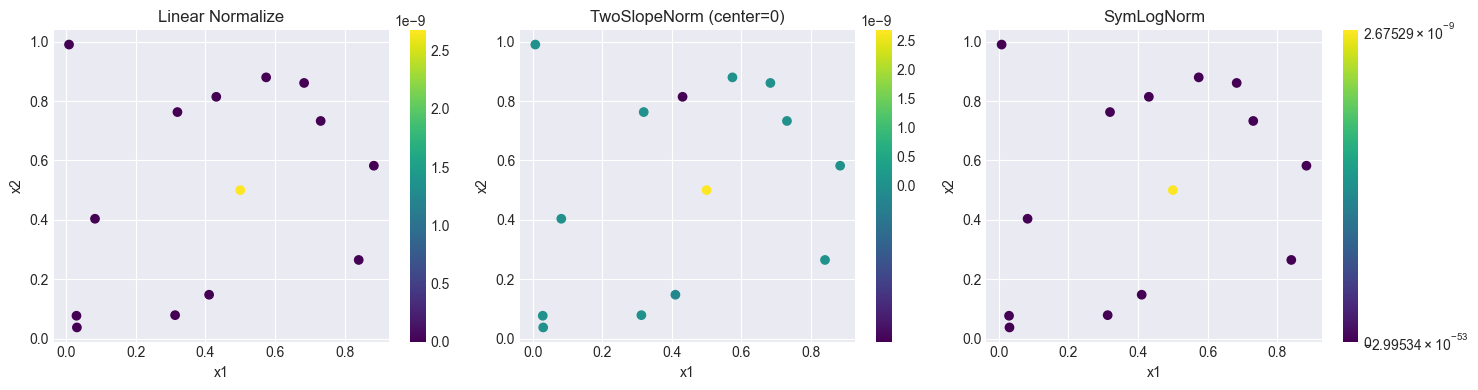

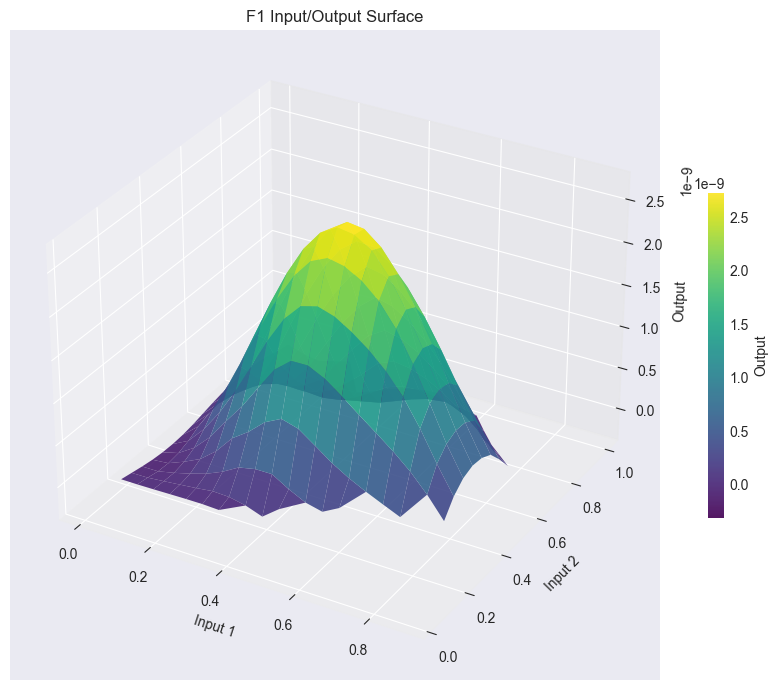

In [2]:
f1_Inputs, f1_Outputs = combineInitialDataAndSubmissionsToDate(1)
f1_inputOutput = np.column_stack((f1_Inputs, f1_Outputs))
f1_inputOutputSorted = sortByLargestOutputDescending(f1_inputOutput)

#Last one is massively out - so remove it.
f1_inputOutputSorted = f1_inputOutputSorted[:-1]

print(np.array2string(f1_inputOutputSorted, floatmode='fixed', precision=6))

#Split into x,y,z
x = f1_inputOutputSorted[:, 0]
y = f1_inputOutputSorted[:, 1]
z = f1_inputOutputSorted[:, 2]


import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, SymLogNorm, Normalize

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#⃣ Default normalization (linear)
norm1 = Normalize(vmin=z.min(), vmax=z.max())
sc1 = axes[0].scatter(x, y, c=z, cmap="viridis", norm=norm1)
axes[0].set_title("Linear Normalize")
plt.colorbar(sc1, ax=axes[0])

# 2️⃣ TwoSlopeNorm (centered at zero)
norm2 = TwoSlopeNorm(vmin=z.min(), vcenter=0, vmax=z.max())
sc2 = axes[1].scatter(x, y, c=z, cmap="viridis", norm=norm2)
axes[1].set_title("TwoSlopeNorm (center=0)")
plt.colorbar(sc2, ax=axes[1])

# 3️⃣ SymLogNorm (best for huge magnitude differences)
norm3 = SymLogNorm(linthresh=1e-6, vmin=z.min(), vmax=z.max())
sc3 = axes[2].scatter(x, y, c=z, cmap="viridis", norm=norm3)
axes[2].set_title("SymLogNorm")
plt.colorbar(sc3, ax=axes[2])


for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata


# Create a grid to interpolate onto (needed for plot_surface)
xi = np.linspace(x.min(), x.max(), 20)
yi = np.linspace(y.min(), y.max(), 20)
xi, yi = np.meshgrid(xi, yi)

# Interpolate scattered points onto the grid
zi = griddata((x, y), z, (xi, yi), method='cubic')

# Plot
surface = plt.figure(figsize=(10, 7))
ax = surface.add_subplot(111, projection='3d')

surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.9)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Output')

ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_zlabel('Output')
ax.set_title('F1 Input/Output Surface')

plt.tight_layout()
plt.show()



[[ 0.702637  0.926564  0.611205]
 [ 0.665800  0.123969  0.538996]
 [ 0.877791  0.778628  0.420586]
 [ 0.845275  0.711120  0.293993]
 [ 0.750921  0.829565  0.259756]
 [ 0.438166  0.685018  0.244619]
 [ 0.454647  0.290455  0.214965]
 [ 0.600000  0.500000  0.144121]
 [ 0.778688  0.970764  0.093698]
 [ 0.350915  0.117067  0.048338]
 [ 0.341750  0.028698  0.038749]
 [ 0.577713  0.771973  0.023106]
 [ 0.338648  0.213867 -0.013858]
 [ 0.092501  0.897042 -0.043957]
 [ 0.142699  0.349005 -0.065624]]


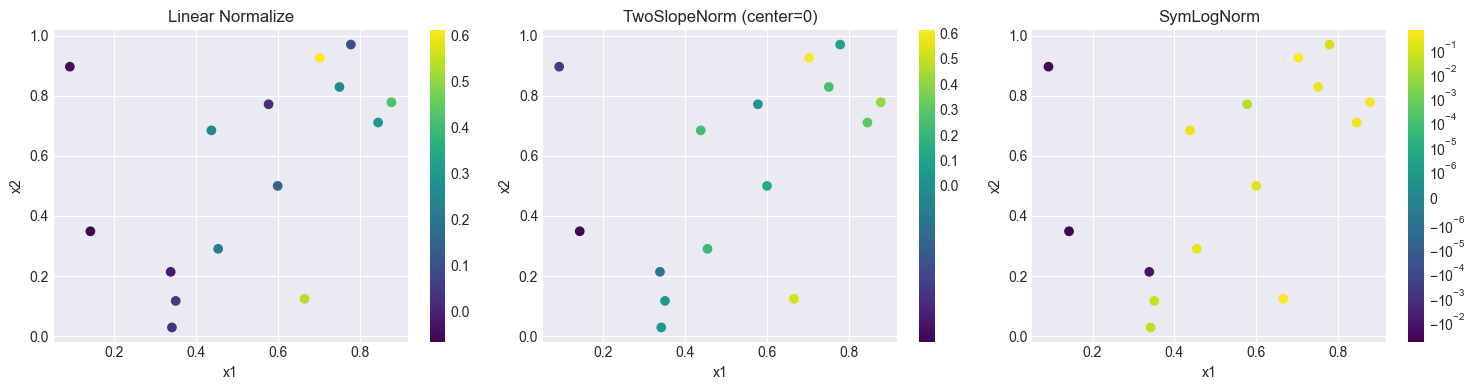

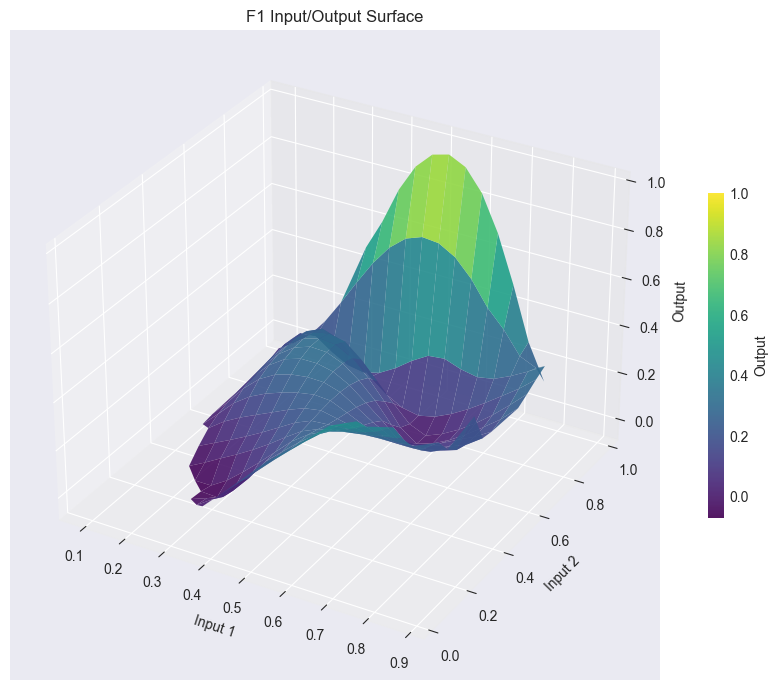

In [16]:
f2_Inputs, f2_Outputs = combineInitialDataAndSubmissionsToDate(2)
f2_inputOutput = np.column_stack((f2_Inputs, f2_Outputs))
f2_inputOutputSorted = sortByLargestOutputDescending(f2_inputOutput)

print(np.array2string(f2_inputOutputSorted, floatmode='fixed', precision=6))

#Split into x,y,z
x = f2_inputOutputSorted[:, 0]
y = f2_inputOutputSorted[:, 1]
z = f2_inputOutputSorted[:, 2]


import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, SymLogNorm, Normalize

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#⃣ Default normalization (linear)
norm1 = Normalize(vmin=z.min(), vmax=z.max())
sc1 = axes[0].scatter(x, y, c=z, cmap="viridis", norm=norm1)
axes[0].set_title("Linear Normalize")
plt.colorbar(sc1, ax=axes[0])

# 2️⃣ TwoSlopeNorm (centered at zero)
norm2 = TwoSlopeNorm(vmin=z.min(), vcenter=0, vmax=z.max())
sc2 = axes[1].scatter(x, y, c=z, cmap="viridis", norm=norm2)
axes[1].set_title("TwoSlopeNorm (center=0)")
plt.colorbar(sc2, ax=axes[1])

# 3️⃣ SymLogNorm (best for huge magnitude differences)
norm3 = SymLogNorm(linthresh=1e-6, vmin=z.min(), vmax=z.max())
sc3 = axes[2].scatter(x, y, c=z, cmap="viridis", norm=norm3)
axes[2].set_title("SymLogNorm")
plt.colorbar(sc3, ax=axes[2])


for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata


# Create a grid to interpolate onto (needed for plot_surface)
xi = np.linspace(x.min(), x.max(), 20)
yi = np.linspace(y.min(), y.max(), 20)
xi, yi = np.meshgrid(xi, yi)

# Interpolate scattered points onto the grid
zi = griddata((x, y), z, (xi, yi), method='cubic')

# Plot
surface = plt.figure(figsize=(10, 7))
ax = surface.add_subplot(111, projection='3d')

surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.9)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Output')

ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_zlabel('Output')
ax.set_title('F1 Input/Output Surface')

plt.tight_layout()
plt.show()

In [4]:
def plot_input_vs_output(data):
    numDimensions = data.shape[1] - 1  # last column is always output
    z = data[:, -1]

    cols = min(3, numDimensions)
    rows = (numDimensions + cols - 1) // cols  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten()  # works for 1D and 2D axes arrays

    for i in range(numDimensions):
        ax = axes[i]
        x = data[:, i]
        ax.scatter(x, z, c=z, cmap='viridis')
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
        ax.set_xlabel(f'Input {i+1}')
        ax.set_ylabel('Output')
        ax.set_title(f'Input {i+1} vs Output')
        #ax.set_yscale('symlog')

    # Hide any unused subplots
    for j in range(numDimensions, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



[[ 5.000000e-001  5.000000e-001  2.675288e-009]
 [ 7.310236e-001  7.329999e-001  7.710875e-016]
 [ 6.834182e-001  8.610575e-001  2.535001e-040]
 [ 5.743292e-001  8.798981e-001  1.033078e-046]
 [ 8.838898e-001  5.822540e-001  6.229856e-048]
 [ 3.194039e-001  7.629594e-001  1.322677e-079]
 [ 8.250725e-002  4.034875e-001  3.606771e-081]
 [ 8.403534e-001  2.647316e-001  3.341771e-124]
 [ 3.050000e-002  3.734800e-002  1.733985e-209]
 [ 7.870000e-003  9.904260e-001  0.000000e+000]
 [ 2.924500e-002  7.675600e-002 -1.187622e-190]
 [ 3.126912e-001  7.872278e-002 -2.089093e-091]
 [ 4.104371e-001  1.475543e-001 -2.159249e-054]
 [ 4.310290e-001  8.143680e-001 -2.995340e-053]]


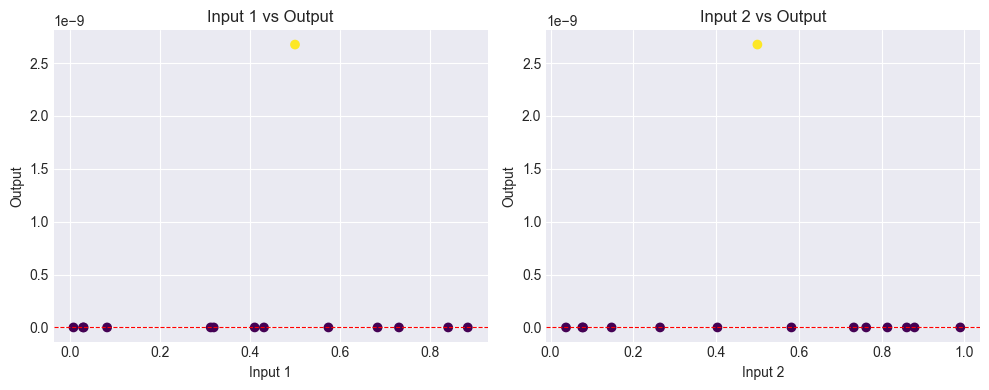

In [5]:
f1_Inputs, f1_Outputs = combineInitialDataAndSubmissionsToDate(1)
f1_inputOutput = np.column_stack((f1_Inputs, f1_Outputs))
f1_inputOutputSorted = sortByLargestOutputDescending(f1_inputOutput)

#Last output is massively out - so remove it.
f1_inputOutputSorted = f1_inputOutputSorted[:-1]
print(np.array2string(f1_inputOutputSorted, floatmode='fixed', precision=6))

plot_input_vs_output(f1_inputOutputSorted)



[[ 0.702637  0.926564  0.611205]
 [ 0.665800  0.123969  0.538996]
 [ 0.877791  0.778628  0.420586]
 [ 0.845275  0.711120  0.293993]
 [ 0.750921  0.829565  0.259756]
 [ 0.438166  0.685018  0.244619]
 [ 0.454647  0.290455  0.214965]
 [ 0.600000  0.500000  0.144121]
 [ 0.778688  0.970764  0.093698]
 [ 0.350915  0.117067  0.048338]
 [ 0.341750  0.028698  0.038749]
 [ 0.577713  0.771973  0.023106]
 [ 0.338648  0.213867 -0.013858]
 [ 0.092501  0.897042 -0.043957]
 [ 0.142699  0.349005 -0.065624]]


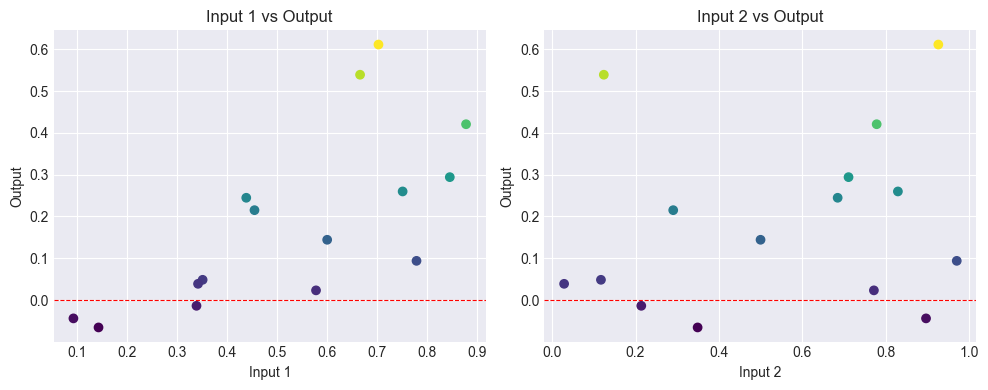

In [6]:
f2_Inputs, f2_Outputs = combineInitialDataAndSubmissionsToDate(2)
f2_inputOutput = np.column_stack((f2_Inputs, f2_Outputs))
f2_inputOutputSorted = sortByLargestOutputDescending(f2_inputOutput)

print(np.array2string(f2_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f2_inputOutputSorted)

[[ 0.371452  0.413066  0.461483 -0.016667]
 [ 0.492581  0.611593  0.340176 -0.034835]
 [ 0.600097  0.725136  0.066089 -0.036378]
 [ 0.220549  0.297825  0.343555 -0.046947]
 [ 0.134622  0.219917  0.458206 -0.048008]
 [ 0.965995  0.861120  0.566829 -0.056758]
 [ 0.431029  0.814368  0.806413 -0.070739]
 [ 0.242114  0.644074  0.272433 -0.087963]
 [ 0.170477  0.697032  0.149169 -0.094190]
 [ 0.431029  0.814368  0.806413 -0.098068]
 [ 0.666014  0.671985  0.246295 -0.105965]
 [ 0.345523  0.941360  0.269363 -0.110621]
 [ 0.534906  0.398501  0.173389 -0.111415]
 [ 0.171525  0.343917  0.248737 -0.112122]
 [ 0.645503  0.397143  0.919771 -0.113869]
 [ 0.046809  0.231360  0.770618 -0.118048]
 [ 0.746912  0.284196  0.226300 -0.131461]
 [ 0.134015  0.028783  0.755137 -0.187030]
 [ 0.965337  0.047492  0.944587 -0.273443]
 [ 0.151837  0.439991  0.990882 -0.398926]]


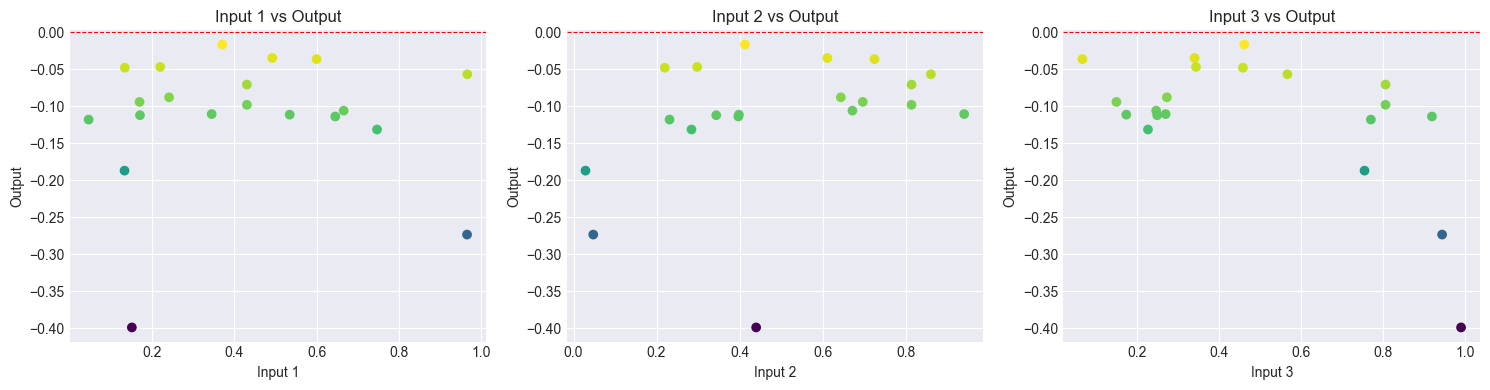

In [7]:
f3_Inputs, f3_Outputs = combineInitialDataAndSubmissionsToDate(3)
f3_inputOutput = np.column_stack((f3_Inputs, f3_Outputs))
f3_inputOutputSorted = sortByLargestOutputDescending(f3_inputOutput)

print(np.array2string(f3_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f3_inputOutputSorted)

[[ 4.315800e-01  4.116090e-01  3.797880e-01  4.129810e-01  5.348195e-01]
 [ 4.300140e-01  4.541360e-01  4.622970e-01  3.515750e-01 -6.329462e-01]
 [ 4.179160e-01  3.873800e-01  3.700490e-01  3.069200e-01 -8.522905e-01]
 [ 5.777656e-01  4.287717e-01  4.258259e-01  2.490074e-01 -4.025542e+00]
 [ 3.260758e-01  4.723669e-01  4.531920e-01  1.058873e-01 -6.702089e+00]
 [ 2.821384e-01  5.059869e-01  5.305308e-01  9.630162e-02 -7.966775e+00]
 [ 1.248712e-01  1.297702e-01  3.844005e-01  2.870761e-01 -1.006963e+01]
 [ 1.703473e-01  7.569591e-01  2.765205e-01  5.312315e-01 -1.156574e+01]
 [ 2.509462e-01  3.369313e-02  1.453800e-01  4.949324e-01 -1.169993e+01]
 [ 2.477083e-01  6.044543e-02  4.218635e-02  4.413243e-01 -1.268168e+01]
 [ 6.260706e-01  5.867513e-01  4.388058e-01  7.788577e-01 -1.274177e+01]
 [ 2.169112e-01  1.660858e-01  2.413723e-01  7.700625e-01 -1.275832e+01]
 [ 7.386130e-01  4.821026e-01  7.093664e-01  5.039700e-01 -1.312278e+01]
 [ 7.328124e-01  1.452500e-01  4.768127e-01  1.3336

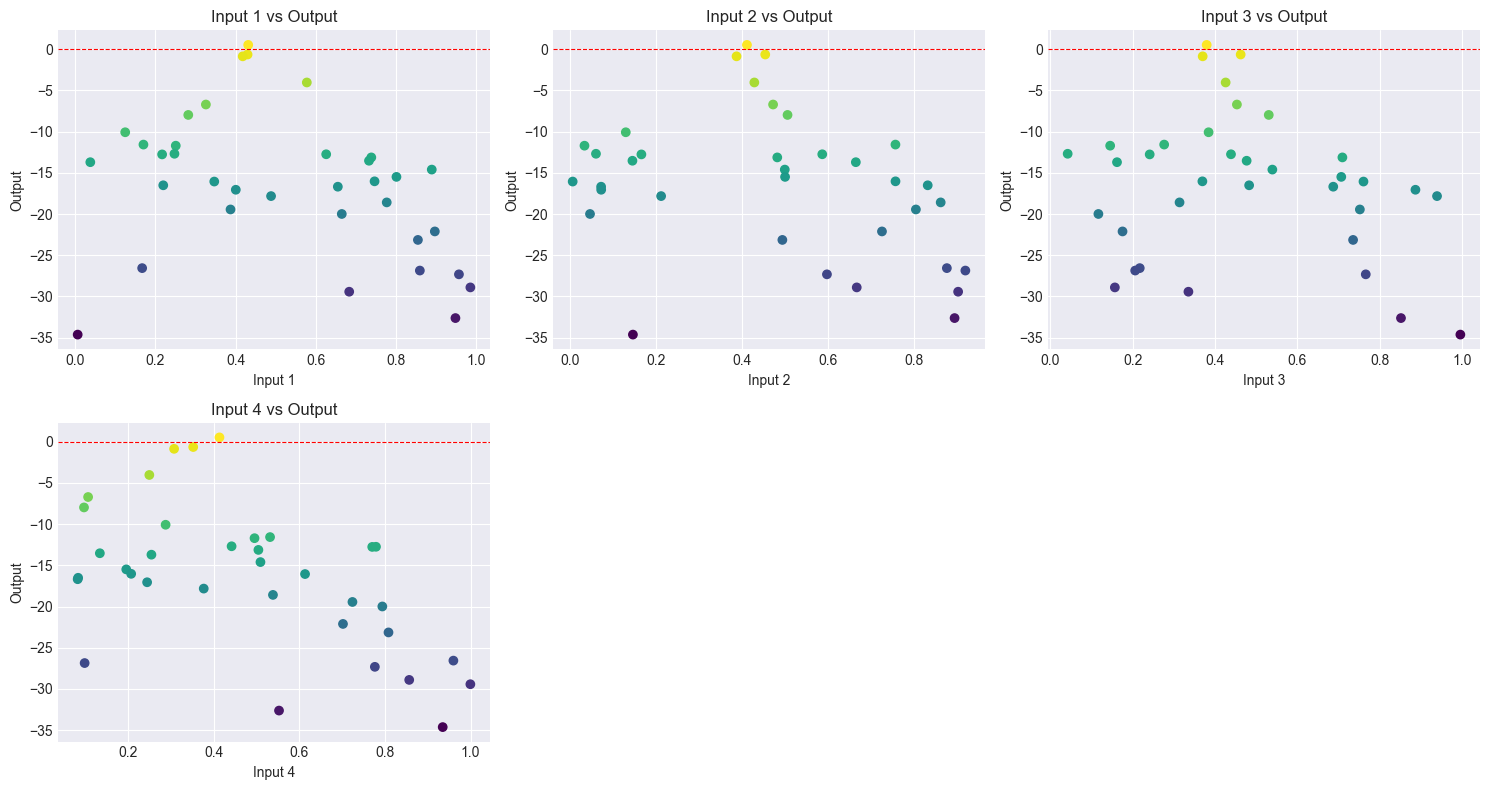

In [8]:
f4_Inputs, f4_Outputs = combineInitialDataAndSubmissionsToDate(4)
f4_inputOutput = np.column_stack((f4_Inputs, f4_Outputs))
f4_inputOutputSorted = sortByLargestOutputDescending(f4_inputOutput)

print(np.array2string(f4_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f4_inputOutputSorted)

[[3.251100e-01 8.389740e-01 1.000000e+00 9.341090e-01 2.263948e+03]
 [3.251100e-01 8.389740e-01 1.000000e+00 9.341090e-01 2.263948e+03]
 [2.983980e-01 8.408080e-01 9.794320e-01 9.188810e-01 1.959096e+03]
 [2.241890e-01 8.464805e-01 8.794842e-01 8.785157e-01 1.088860e+03]
 [1.198792e-01 8.625403e-01 6.433313e-01 8.498038e-01 4.316128e+02]
 [4.389334e-01 7.740918e-01 3.781671e-01 9.336962e-01 3.558068e+02]
 [8.364780e-01 1.936096e-01 6.638927e-01 7.856489e-01 2.583705e+02]
 [4.634423e-01 6.300245e-01 1.079065e-01 9.576439e-01 2.332236e+02]
 [3.523563e-01 3.222415e-01 1.169794e-01 4.731125e-01 1.095719e+02]
 [9.249010e-01 5.017400e-01 2.203750e-01 3.912650e-01 8.694294e+01]
 [5.111418e-01 8.179570e-01 7.287104e-01 1.123536e-01 7.972913e+01]
 [6.834322e-01 1.186626e-01 8.290459e-01 5.675766e-01 7.843439e+01]
 [1.914471e-01 3.819337e-02 6.074178e-01 4.145841e-01 6.444344e+01]
 [5.839734e-01 1.472426e-01 3.480975e-01 4.286147e-01 6.442015e+01]
 [3.068887e-01 3.168781e-01 6.226345e-01 9.53990

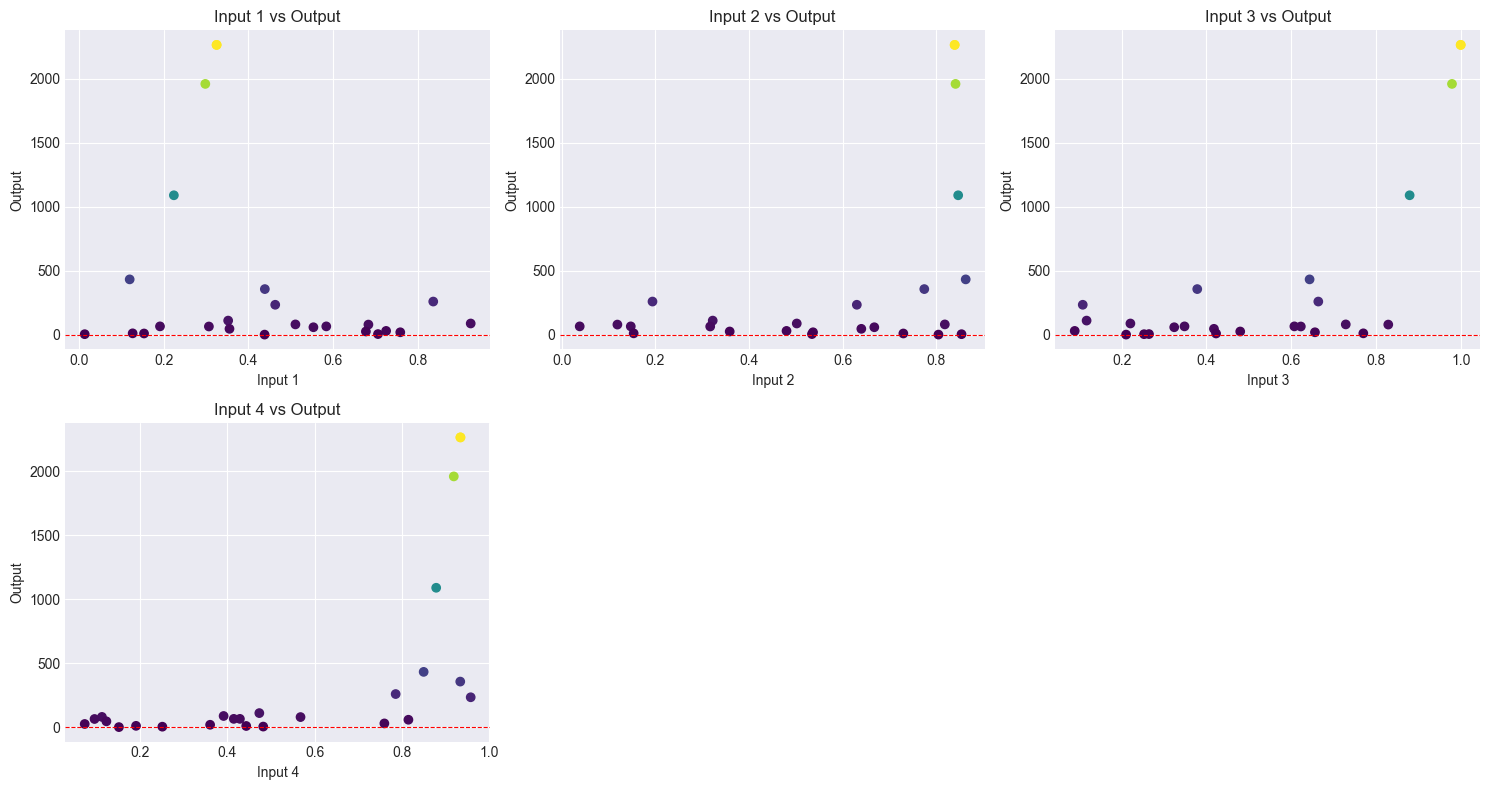

In [9]:
f5_Inputs, f5_Outputs = combineInitialDataAndSubmissionsToDate(5)
f5_inputOutput = np.column_stack((f5_Inputs, f5_Outputs))
f5_inputOutputSorted = sortByLargestOutputDescending(f5_inputOutput)

print(np.array2string(f5_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f5_inputOutputSorted)

[[ 0.400740  0.365117  0.465329  0.765461  0.143118 -0.277658]
 [ 0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265]
 [ 0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237]
 [ 0.585939  0.538496  0.989507  0.863517  0.003667 -0.897936]
 [ 0.782880  0.536336  0.443284  0.859700  0.010326 -0.935757]
 [ 0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785]
 [ 0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955]
 [ 0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786]
 [ 0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049]
 [ 0.432166  0.715618  0.341819  0.705000  0.614962 -1.294247]
 [ 0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116]
 [ 0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682]
 [ 0.378662  0.929790  0.610430  0.888797  0.694790 -1.407600]
 [ 0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058]
 [ 0.727495  0.494342  0.160947  0.347883  0.276223 -1.611645]
 [ 0.629308  0.803484  0.811408  0.045613  0.110624 -1.

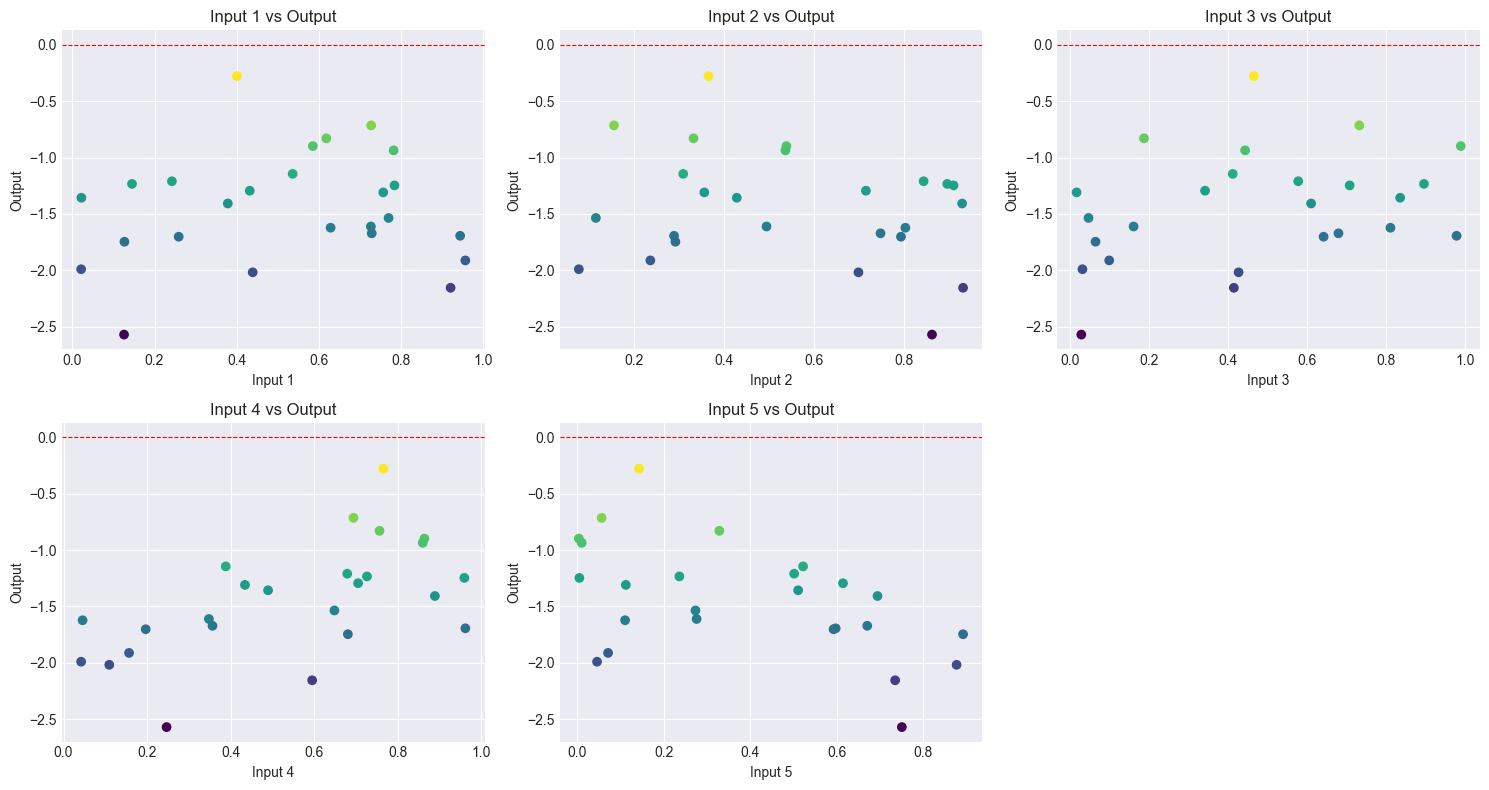

In [10]:
f6_Inputs, f6_Outputs = combineInitialDataAndSubmissionsToDate(6)
f6_inputOutput = np.column_stack((f6_Inputs, f6_Outputs))
f6_inputOutputSorted = sortByLargestOutputDescending(f6_inputOutput)

print(np.array2string(f6_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f6_inputOutputSorted)

[[3.161700e-02 4.443610e-01 2.799560e-01 1.730890e-01 3.666070e-01
  7.319880e-01 1.627093e+00]
 [5.789554e-02 4.916722e-01 2.474222e-01 2.181184e-01 4.204283e-01
  7.309698e-01 1.364968e+00]
 [8.816467e-01 2.044502e-01 4.144744e-01 4.203847e-01 2.649150e-01
  7.306602e-01 6.751416e-01]
 [1.486470e-01 3.394336e-02 7.288056e-01 3.160665e-01 2.176938e-02
  5.169178e-01 6.115255e-01]
 [2.726238e-01 3.244954e-01 8.971088e-01 8.329512e-01 1.540627e-01
  7.958636e-01 6.044327e-01]
 [5.430026e-01 9.246939e-01 3.415675e-01 6.464858e-01 7.184403e-01
  3.431327e-01 5.627531e-01]
 [6.661051e-02 5.280451e-01 8.160952e-01 9.610171e-01 8.650933e-02
  7.777882e-01 5.164572e-01]
 [1.759775e-01 6.244165e-01 2.955420e-01 4.695528e-01 9.776977e-02
  7.281411e-01 4.753955e-01]
 [4.176263e-01 6.409998e-02 2.456688e-01 5.590408e-01 1.915314e-01
  2.546409e-01 2.748925e-01]
 [6.302176e-01 8.380969e-01 6.800131e-01 7.318951e-01 5.267367e-01
  3.484292e-01 2.730468e-01]
 [9.424508e-01 3.774396e-01 4.861223e-01

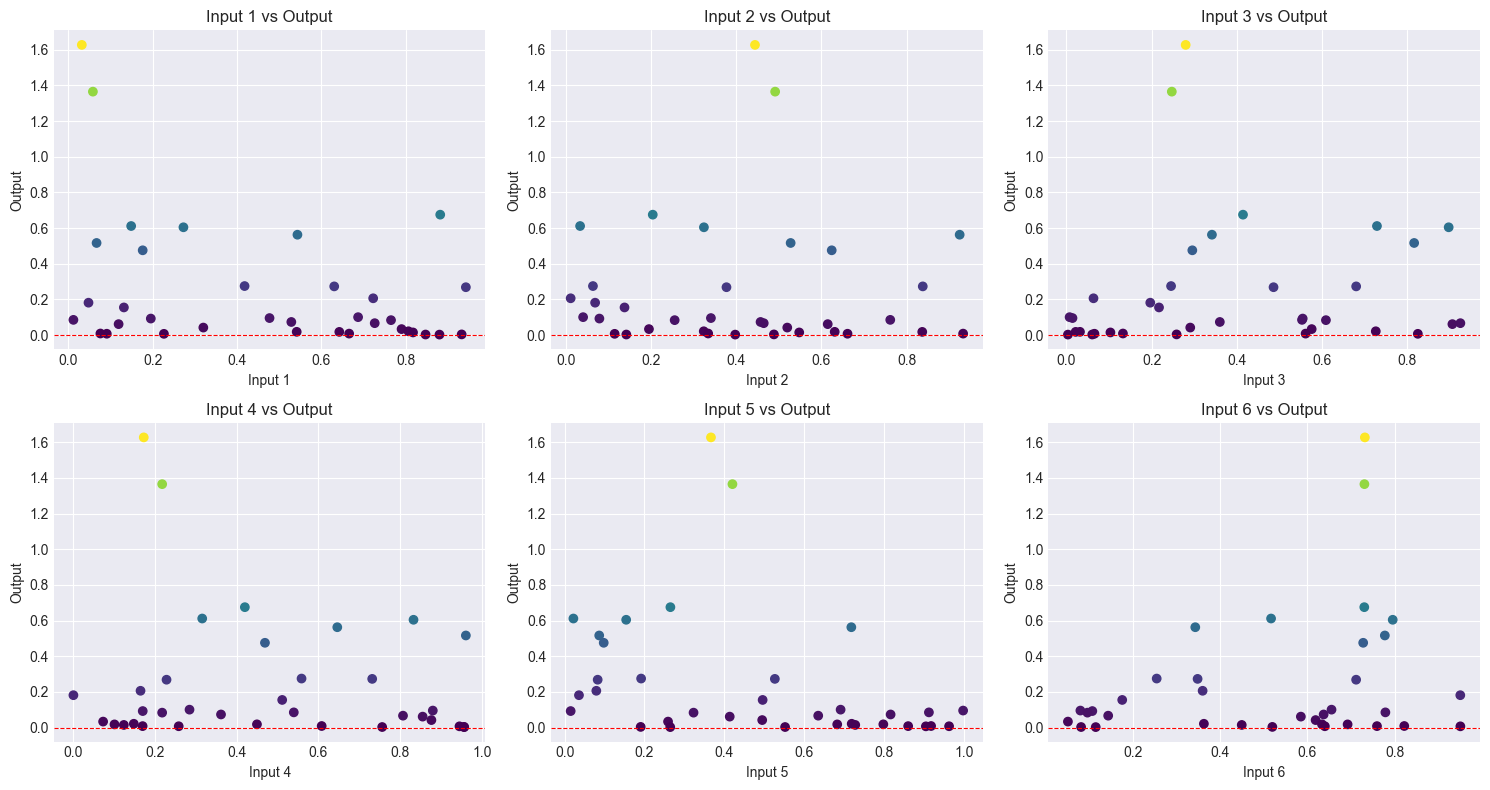

In [13]:
f7_Inputs, f7_Outputs = combineInitialDataAndSubmissionsToDate(7)
f7_inputOutput = np.column_stack((f7_Inputs, f7_Outputs))
f7_inputOutputSorted = sortByLargestOutputDescending(f7_inputOutput)

print(np.array2string(f7_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f7_inputOutputSorted)

[[1.199190e-01 1.575910e-01 7.379700e-02 0.000000e+00 9.460320e-01
  2.338210e-01 4.595400e-02 5.690100e-01 9.838102e+00]
 [5.644741e-02 6.595555e-02 2.292868e-02 3.878647e-02 4.039354e-01
  8.010553e-01 4.883070e-01 8.930850e-01 9.598482e+00]
 [1.926399e-01 6.306773e-01 4.167958e-01 4.905293e-01 7.960860e-01
  6.545671e-01 2.762412e-01 2.955176e-01 9.344274e+00]
 [4.812453e-01 1.024607e-01 2.194859e-01 6.773224e-01 2.475092e-01
  2.443409e-01 1.638245e-01 7.159616e-01 9.183005e+00]
 [1.451203e-01 1.193275e-01 4.208882e-01 3.876086e-01 1.554228e-01
  8.751716e-01 5.105597e-01 7.286106e-01 9.141639e+00]
 [4.432925e-02 1.358149e-02 2.581982e-01 5.776442e-01 5.127992e-02
  1.585631e-01 5.910301e-01 7.795293e-02 9.013075e+00]
 [1.994980e-01 2.882000e-03 2.253190e-01 9.583650e-01 9.891360e-01
  9.934780e-01 1.413780e-01 2.729000e-02 8.976766e+00]
 [1.435503e-01 9.374145e-01 2.323248e-01 9.043485e-03 4.145789e-01
  4.093252e-01 5.537785e-01 2.058408e-01 8.976554e+00]
 [2.894663e-02 2.827906e

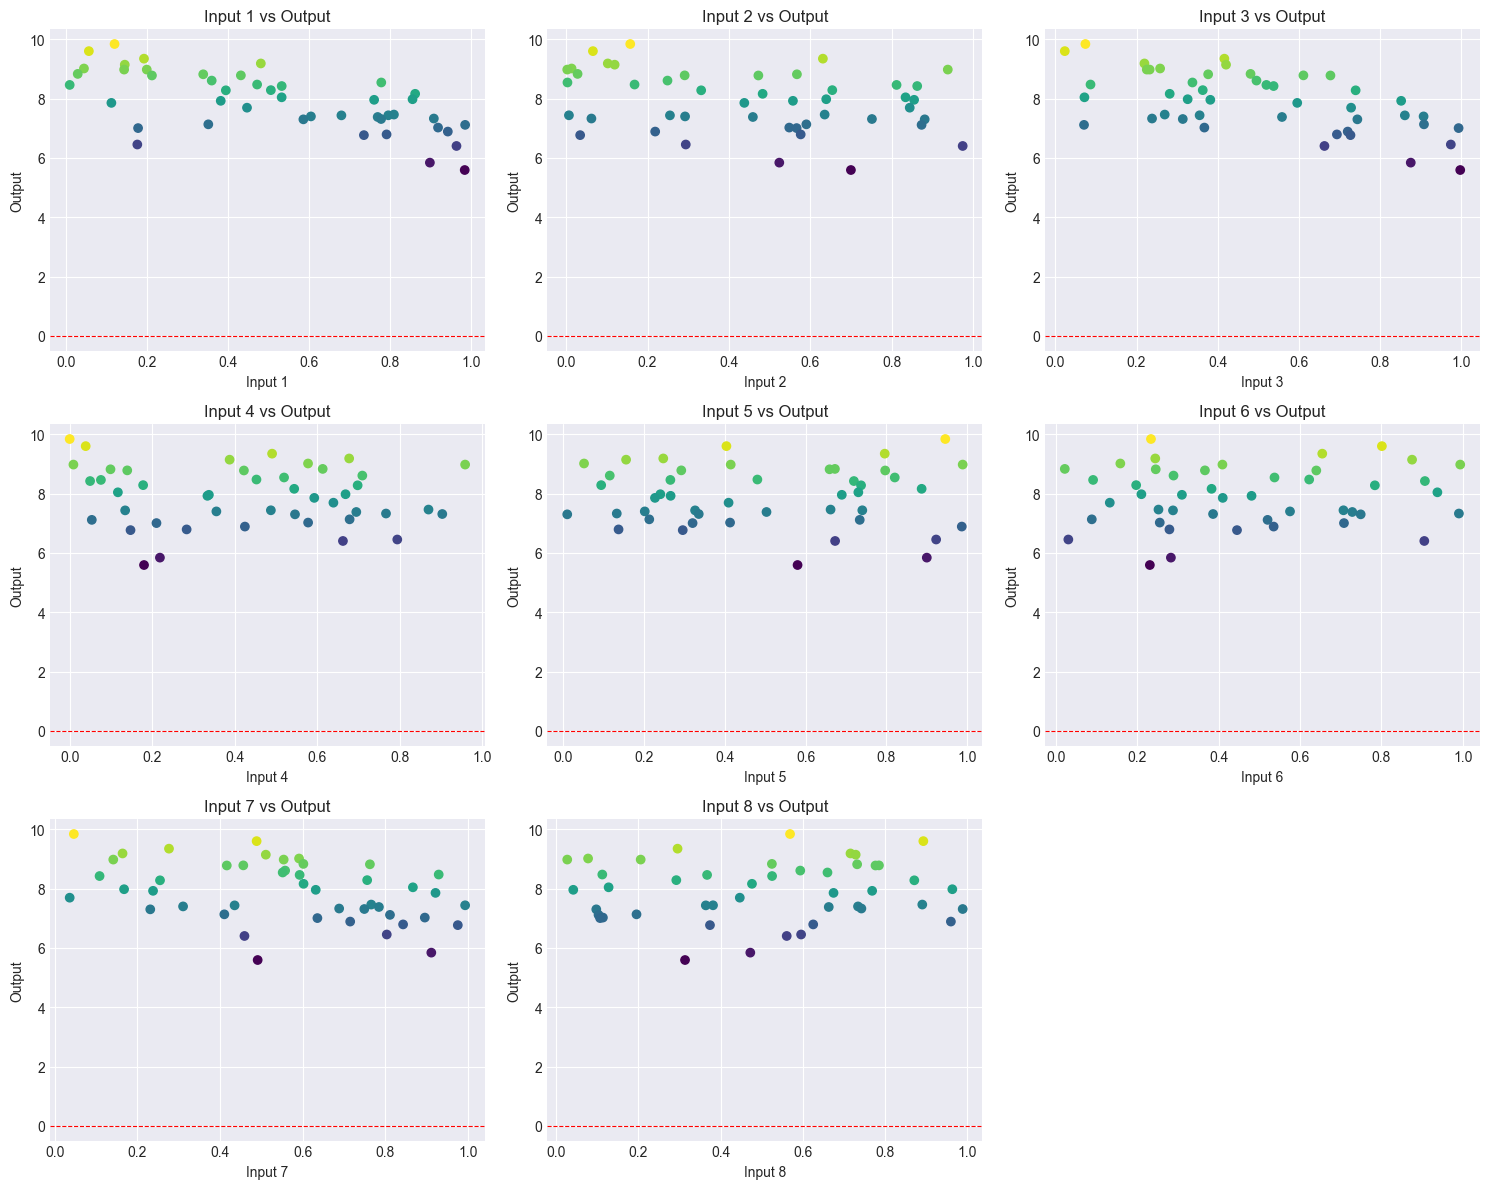

In [15]:
f8_Inputs, f8_Outputs = combineInitialDataAndSubmissionsToDate(8)
f8_inputOutput = np.column_stack((f8_Inputs, f8_Outputs))
f8_inputOutputSorted = sortByLargestOutputDescending(f8_inputOutput)

print(np.array2string(f8_inputOutputSorted, floatmode='fixed', precision=6))
plot_input_vs_output(f8_inputOutputSorted)